Text(0.5, 1.0, "$y' = - \\frac{x^2}{1 - x^2 - y^2}$")

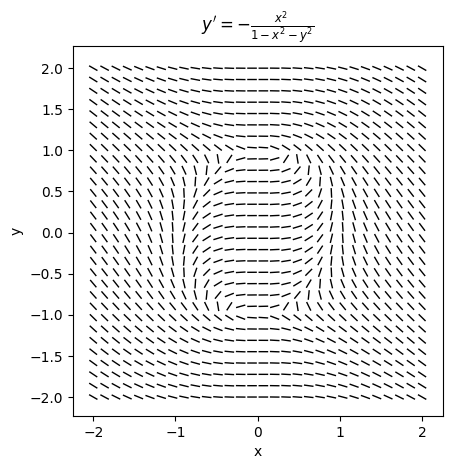

In [1]:
import numpy as np                         # import library numpy untuk perhitungan numerik
from matplotlib import pyplot as plt       # import pyplot dari matplotlib untuk plotting

# Direction Field
def direction_field(x_min, x_max, y_min, y_max, n_step, length, func, ax):  # fungsi untuk membuat direction field
    
    np.seterr(divide='ignore', invalid='ignore')  # menghindari error pembagian nol
    
    x_vals = np.linspace(x_min, x_max, n_step)    # membuat array nilai x
    y_vals = np.linspace(y_min, y_max, n_step)    # membuat array nilai y
    X, Y = np.meshgrid(x_vals, y_vals)            # membuat grid 2D dari x dan y
    
    slope = func(X, Y)                            # menghitung kemiringan (dy/dx)
    slope = np.where(slope == np.inf, 10**3, slope)   # mengganti nilai tak hingga positif
    slope = np.where(slope == -np.inf, -10**3, slope) # mengganti nilai tak hingga negatif
    
    delta = length * np.cos(np.arctan(slope))     # menghitung panjang segmen garis arah
    
    X1 = X - delta                                # titik awal x
    X2 = X + delta                                # titik akhir x
    Y1 = slope * (X1 - X) + Y                     # titik awal y
    Y2 = slope * (X2 - X) + Y                     # titik akhir y
    
    ax.plot([X1.ravel(), X2.ravel()],             # plot garis arah bagian x
            [Y1.ravel(), Y2.ravel()],             # plot garis arah bagian y
            'k-', linewidth=1)                    # warna hitam dengan ketebalan garis

# differential equations
def my_ode(x, y):                                 # fungsi persamaan diferensial
    dydx = x**2 / (1 - x**2 - y**2)               # rumus dy/dx
    return dydx                                   # mengembalikan nilai turunan

# Make the plot
fig, ax1 = plt.subplots()                        # membuat figure dan axis
direction_field(x_min=-2, x_max=2, y_min=-2, y_max=2, 
                n_step=30, length=0.05, func=my_ode, ax=ax1)  # memanggil fungsi direction field

ax1.set_xlabel('x')                              # memberi label sumbu x
ax1.set_ylabel('y')                              # memberi label sumbu y
ax1.axis('square')                               # membuat skala sumbu sama (kotak)

ax1.set_title(r"$y' = - \frac{x^2}{1 - x^2 - y^2}$")  # memberi judul dengan format latex

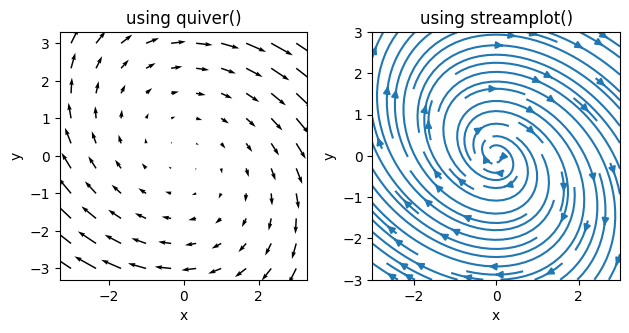

In [2]:
import numpy as np                      # import numpy untuk perhitungan array
import matplotlib.pyplot as plt         # import pyplot untuk membuat grafik

x_vals = np.linspace(-3, 3, 10)        # membuat nilai x dari -3 sampai 3 sebanyak 10 titik
y_vals = x_vals                        # menyamakan nilai y dengan x
X, Y = np.meshgrid(x_vals, y_vals)     # membuat grid koordinat X dan Y

dx_dt = X + 2*Y                        # persamaan dx/dt
dy_dt = -2*X                           # persamaan dy/dt

fig = plt.figure()                     # membuat figure kosong
ax1 = fig.add_subplot(1, 2, 1)         # membuat subplot pertama (kiri)
ax1.quiver(X, Y, dx_dt, dy_dt)        # menampilkan vektor arah dengan quiver
ax1.set_title('using quiver()')       # memberi judul grafik pertama
ax1.set_xlabel('x')                   # memberi label sumbu x
ax1.set_ylabel('y')                   # memberi label sumbu y
ax1.axis('square')                    # membuat skala sumbu sama

ax2 = fig.add_subplot(1, 2, 2)         # membuat subplot kedua (kanan)
ax2.streamplot(X, Y, dx_dt, dy_dt)    # menampilkan aliran vektor dengan streamplot
ax2.set_title('using streamplot()')   # memberi judul grafik kedua
ax2.set_xlabel('x')                   # memberi label sumbu x
ax2.set_ylabel('y')                   # memberi label sumbu y
ax2.axis('square')                    # membuat skala sumbu sama

fig.tight_layout()                    # merapikan tata letak antar grafik

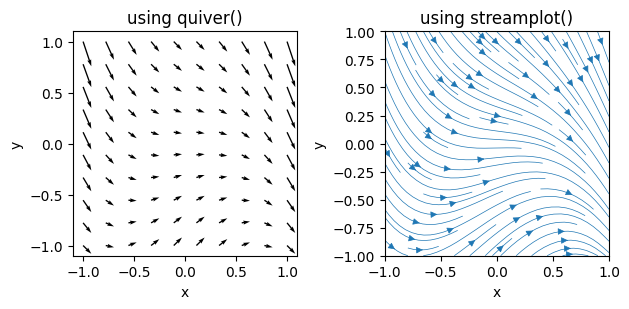

In [3]:
import numpy as np                          # import numpy untuk operasi numerik
import matplotlib.pyplot as plt             # import matplotlib untuk plotting

x_vals = np.linspace(-1, 1, 10)            # membuat array nilai x dari -1 sampai 1
y_vals = x_vals                            # menyamakan nilai y dengan x

X, Y = np.meshgrid(x_vals, y_vals)         # membuat grid koordinat 2D

dx_dt = np.ones_like(X)                    # nilai dx/dt (konstan 1 untuk semua titik)
dy_dt = -Y - 2 * X**2                      # persamaan dy/dt

# Making plot
fig = plt.figure()                         # membuat figure kosong
ax1 = fig.add_subplot(1, 2, 1)             # membuat subplot pertama (kiri)
ax1.quiver(X, Y, dx_dt, dy_dt)             # menampilkan direction field dengan quiver
ax1.set_title('using quiver()')            # memberi judul grafik pertama
ax1.set_xlabel('x')                        # memberi label sumbu x
ax1.set_ylabel('y')                        # memberi label sumbu y
ax1.axis('square')                         # membuat skala sumbu menjadi sama

ax2 = fig.add_subplot(1, 2, 2)             # membuat subplot kedua (kanan)
ax2.streamplot(X, Y, dx_dt, dy_dt, linewidth=0.5)  # menampilkan aliran vektor dengan streamplot
ax2.set_title('using streamplot()')        # memberi judul grafik kedua
ax2.set_xlabel('x')                        # memberi label sumbu x
ax2.set_ylabel('y')                        # memberi label sumbu y
ax2.axis('square')                         # membuat skala sumbu menjadi sama

fig.tight_layout()                         # merapikan layout agar tidak bertumpuk

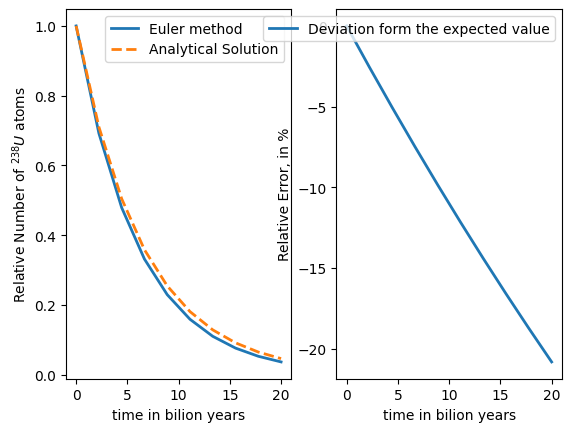

In [4]:
import matplotlib.pyplot as plt                 # import pyplot untuk plotting grafik
import numpy as np                             # import numpy untuk perhitungan numerik

# Euler Method
def euler_method(n0, decay_const, t_final, n_steps):   # fungsi metode Euler
    steps = n_steps                             # menyimpan jumlah langkah iterasi
    delta_t = t_final / n_steps                 # menghitung selang waktu (Δt)
    t_vals = np.linspace(0, steps * delta_t, steps)  # membuat array waktu
    n_vals = np.zeros(t_vals.shape, float)      # membuat array n dengan nilai awal nol
    n_vals[0] = n0                              # menetapkan nilai awal n(0)
    
    for i in range(0, len(t_vals) - 1):         # perulangan metode Euler
        n_vals[i+1] = n_vals[i] * (1 - decay_const * delta_t)  # rumus Euler
    
    n_ratio = n_vals / n0                       # menghitung rasio n terhadap n0
    return n_vals, n_ratio, t_vals              # mengembalikan hasil perhitungan

ne, ner, te = euler_method(n0=10000, decay_const=1.54e-1, t_final=20, n_steps=10)  # memanggil fungsi Euler

# Analytical solution ... in the same points of the Euler method
def analytical_solution(n0, decay_const, t_final, n_steps):  # fungsi solusi analitik
    mid_points = n_steps                         # jumlah titik antara
    delta_t = t_final / n_steps                  # menghitung selang waktu
    t2_vals = np.linspace(0, mid_points * delta_t, mid_points)  # array waktu
    n2_vals = n0 * np.exp(-decay_const * t2_vals)  # rumus solusi eksponensial
    n2_ratio = n2_vals / n0                     # rasio terhadap nilai awal
    return n2_vals, n2_ratio, t2_vals           # mengembalikan hasil analitik

na, nar, ta = analytical_solution(n0=10000, decay_const=1.54e-1, t_final=20, n_steps=10)  # panggil solusi analitik

euler_rel_error = 100 * (ne - na) / na         # menghitung error relatif Euler (%)

fig = plt.figure()                             # membuat figure
ax1 = fig.add_subplot(1, 2, 1)                 # subplot pertama
ax1.plot(te, ner, linestyle='-', linewidth=2, label='Euler method')  # plot Euler
ax1.plot(ta, nar, linestyle='--', linewidth=2, label='Analytical Solution')  # plot analitik
ax1.set_ylabel('Relative Number of $^{238}U$ atoms')  # label sumbu y
ax1.set_xlabel('time in bilion years')         # label sumbu x
ax1.legend()                                   # menampilkan legenda

ax2 = fig.add_subplot(1, 2, 2)                 # subplot kedua
ax2.plot(te, euler_rel_error, linestyle='-', linewidth=2, label='Deviation form the expected value')  # plot error
ax2.set_ylabel('Relative Error, in %')         # label sumbu y
ax2.set_xlabel('time in bilion years')         # label sumbu x
ax2.legend()                                   # menampilkan legenda

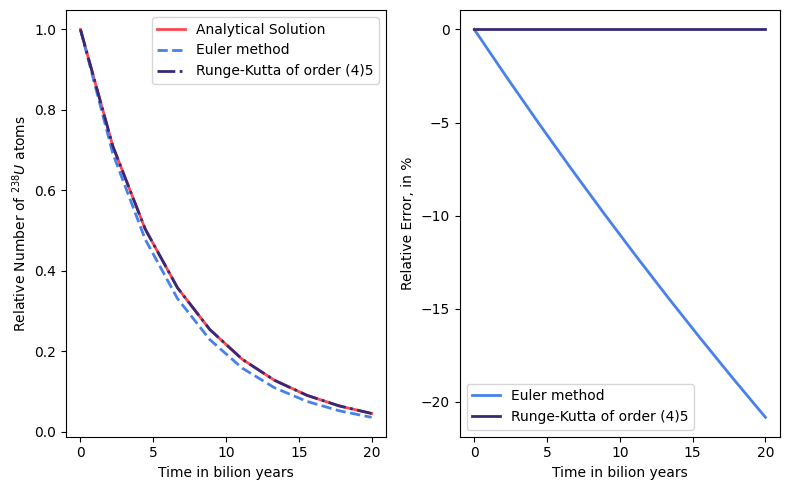

In [5]:
import matplotlib.pyplot as plt                 # import pyplot untuk membuat grafik
import numpy as np                              # import numpy untuk operasi numerik
from scipy.integrate import ode                 # import fungsi ode dari scipy

# using scipy.integrate.ode
def ode_solution(n0, decay_const, t_final, n_steps):   # fungsi solusi numerik dengan ODE
    steps = n_steps                             # jumlah langkah
    t_vals = np.linspace(0, t_final, steps)     # membuat array waktu
    n_vals = np.zeros(t_vals.shape, float)      # array hasil dengan nilai awal nol
    
    def f(t, y, decay_const):                   # fungsi diferensial dy/dt
        return -decay_const * y                 # persamaan peluruhan eksponensial
    
    solver = ode(f).set_integrator('dopri5')    # membuat solver Runge-Kutta orde (4)5
    y0 = n0                                     # nilai awal
    t0 = 0                                      # waktu awal
    
    solver.set_initial_value(y0, t0)            # set kondisi awal
    solver.set_f_params(decay_const)            # set parameter fungsi
    
    k = 1                                       # indeks iterasi
    n_vals[0] = n0                              # isi nilai awal array
    
    while solver.successful() and solver.t < t_final:  # loop selama solver berhasil
        n_vals[k] = solver.integrate(t_vals[k])[0]     # integrasi ke titik berikutnya
        k += 1                                  # increment indeks
    
    n_ratio = n_vals / n0                       # rasio terhadap nilai awal
    return n_vals, n_ratio, t_vals              # mengembalikan hasil

# Analytical solution
na, nar, ta = analytical_solution(n0=10000, decay_const=1.54e-1, t_final=20, n_steps=10)  # solusi analitik

# Euler method
ne, ner, te = euler_method(n0=10000, decay_const=1.54e-1, t_final=20, n_steps=10)         # metode Euler
euler_error = 100 * (ne - na) / na              # menghitung error Euler (%)

# Runge-Kutta of order (4)5
n_ode, noder, tode = ode_solution(n0=10000, decay_const=1.54e-1, t_final=20, n_steps=10)  # solusi ODE
ode_error = 100 * (n_ode - na) / na            # menghitung error ODE (%)

# Make the plot
fig = plt.figure(figsize=(8, 5))               # membuat figure dengan ukuran tertentu

ax1 = fig.add_subplot(1, 2, 1)                 # subplot pertama
ax1.plot(ta, nar, linestyle='-', linewidth=2, label='Analytical Solution', c='#ff464a')  # plot analitik
ax1.plot(te, ner, linestyle='--', linewidth=2, label='Euler method', c='#4881e9')        # plot Euler
ax1.plot(tode, noder, linestyle='-.', linewidth=2, label='Runge-Kutta of order (4)5', c='#342a77')  # plot RK
ax1.set_ylabel('Relative Number of $^{238}U$ atoms')  # label sumbu y
ax1.set_xlabel('Time in bilion years')         # label sumbu x
ax1.legend()                                   # menampilkan legenda

ax2 = fig.add_subplot(1, 2, 2)                 # subplot kedua
ax2.plot(te, euler_error, linestyle='-', linewidth=2, c='#4881e9', label='Euler method')  # plot error Euler
ax2.plot(tode, ode_error, linestyle='-', linewidth=2, c='#342a77', label='Runge-Kutta of order (4)5')  # plot error RK
ax2.set_ylabel('Relative Error, in %')         # label sumbu y
ax2.set_xlabel('Time in bilion years')         # label sumbu x
ax2.legend()                                   # menampilkan legenda

fig.tight_layout()                             # merapikan layout grafik

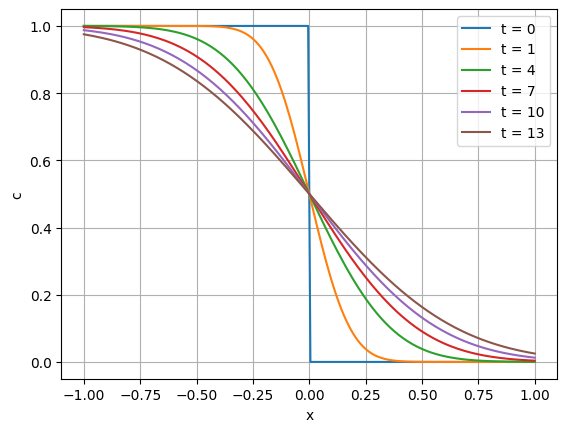

In [6]:
import numpy as np                      # import numpy untuk operasi numerik
from scipy import special              # import modul special dari scipy (fungsi matematika khusus)
import matplotlib.pyplot as plt        # import pyplot untuk membuat grafik

def plane_diff_1d(t, D, x0=0, xmin=-1, xmax=1, c_left=1, c_right=0, num_pts=200):  # fungsi difusi 1D
    n = num_pts                        # jumlah titik (diubah dari num_points → num_pts)
    x = np.linspace(xmin, xmax, n)     # membuat array x dari xmin ke xmax
    delta_c = c_left - c_right         # selisih konsentrasi kiri dan kanan

    c0 = np.piecewise(x, [x < x0, x >= x0], [c_left, c_right])  # kondisi awal (step function)
    c = 0.5 * delta_c * (special.erfc((x - x0)/(2 * np.sqrt(D * t))))  # solusi difusi dengan fungsi erfc

    return x, c, c0                    # mengembalikan nilai x, c (hasil), dan c0 (awal)

D_val = 0.01                           # koefisien difusi (diubah dari D → D_val)

fig, ax = plt.subplots()               # membuat figure dan axis untuk plotting

for t_val in range(1, 14, 3):          # loop waktu dari 1 sampai 13 dengan step 3 (diubah t → t_val)
    x, c, c0 = plane_diff_1d(t=t_val, D=D_val)  # memanggil fungsi dengan parameter waktu dan difusi
    if t_val == 1:                     # jika waktu pertama (t = 1 dianggap awal)
        leg = "t = " + str(t_val)      # label legend untuk waktu
        plt.plot(x, c0, label="t = 0")# plot kondisi awal
    leg = "t = " + str(t_val)          # membuat label legend untuk tiap waktu
    ax.plot(x, c, label=leg)           # plot hasil difusi untuk tiap waktu

ax.grid()                              # menampilkan grid pada grafik
ax.set_xlabel('x')                     # memberi label sumbu x
ax.set_ylabel('c')                     # memberi label sumbu y (konsentrasi)
ax.legend()                            # menampilkan legend

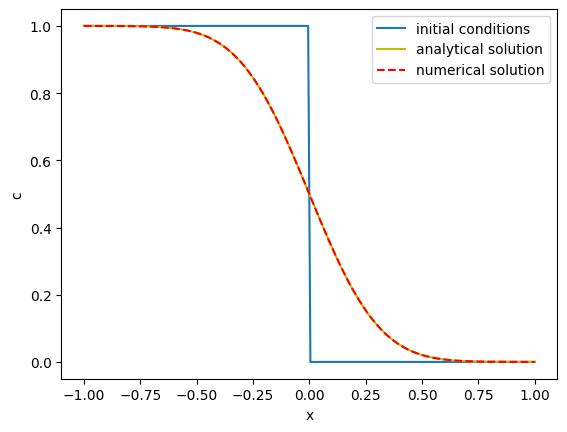

In [7]:
def ftcs(u_arr, dx, D_val, dt_val):          # fungsi FTCS untuk metode numerik difusi
    d2u_dx2 = np.zeros(u_arr.shape, float)   # array untuk turunan kedua terhadap x

    for i in range(1, len(u_arr)-1):         # loop untuk titik interior (bukan batas)
        d2u_dx2[i] = (u_arr[i+1] - 2*u_arr[i] + u_arr[i-1]) / dx**2  # turunan kedua (central difference)

    i = 0                                    # indeks batas kiri
    d2u_dx2[i] = (u_arr[i+1] - 2*u_arr[i] + u_arr[i]) / dx**2  # kondisi batas kiri (Neumann)

    i = len(u_arr) - 1                       # indeks batas kanan
    d2u_dx2[i] = (u_arr[i] - 2*u_arr[i] + u_arr[i-1]) / dx**2  # kondisi batas kanan (Neumann)

    u_next = u_arr + dt_val * D_val * d2u_dx2  # update solusi pakai metode Euler
    return u_next                            # mengembalikan hasil update

dt_val = 0.001                               # step size waktu
tf = 3                                       # waktu akhir simulasi

def compute_d_const(u_arr, D_val, dx, dt_val, tf):  # fungsi komputasi difusi numerik
    nsteps = tf / dt_val                     # jumlah langkah waktu
    u1 = u_arr                              # inisialisasi kondisi awal

    for i in range(int(nsteps)):            # loop sebanyak jumlah langkah waktu
        u1 = ftcs(u1, dx, D_val, dt_val)    # update nilai u tiap langkah

    return u1                               # mengembalikan hasil akhir

x, c, c0 = plane_diff_1d(t=tf, D=D_val)     # ✅ sudah diperbaiki (pakai D_val)
dx = x[1] - x[0]                            # step size ruang
u_init = c0                                 # kondisi awal

c1 = compute_d_const(u_init, D_val, dx, dt_val, tf)  # solusi numerik

fig, ax = plt.subplots()                    # membuat figure dan axis
ax.plot(x, c0, label='initial conditions')  # plot kondisi awal
ax.plot(x, c, 'y', label='analytical solution')  # plot solusi analitik
ax.plot(x, c1, 'r--', label='numerical solution')  # plot solusi numerik
ax.set_xlabel('x')                          # label sumbu x
ax.set_ylabel('c')                          # label sumbu y
ax.legend()                                 # menampilkan legenda

In [8]:
def numpy_ftcs(u_arr, D_val, dx, dt_val):        # fungsi FTCS versi numpy (vektorisasi)
    d2u_dx2 = np.zeros(u_arr.shape, float)       # array untuk turunan kedua terhadap x

    d2u_dx2[1:-1] = (u_arr[2:] - 2 * u_arr[1:-1] + u_arr[:-2]) / dx**2  # turunan kedua (central difference, vectorized)

    # Neumann boundary conditions at i=0 and i=len(u_arr)-1
    i = 0                                        # indeks batas kiri
    d2u_dx2[i] = (u_arr[i+1] - 2 * u_arr[i] + u_arr[i]) / dx**2  # kondisi batas kiri (Neumann)

    i = len(u_arr) - 1                           # indeks batas kanan
    d2u_dx2[i] = (u_arr[i] - 2 * u_arr[i] + u_arr[i-1]) / dx**2  # kondisi batas kanan (Neumann)

    # Euler method for the time domain
    u_next = u_arr + dt_val * D_val * d2u_dx2    # update solusi dengan metode Euler
    return u_next                                # mengembalikan hasil update

In [9]:
import numpy as np                         # untuk operasi numerik (array, matematika)
import matplotlib.pyplot as plt            # untuk membuat grafik/plot
import pandas as pd                        # untuk membaca dan mengolah data (excel, csv)

# Model parameters
temp_C = 1200.0                           # suhu dalam derajat Celcius
dx_val = 4.12                              # jarak rata-rata antar titik (mikron)
dt_val = 0.9 * 1e4                         # langkah waktu
R_const = 8.3144 * (temp_C + 273.15)       # konstanta gas dikali suhu (Kelvin)
r_param = dt_val / dx_val**2               # parameter rasio difusi

# Initial Conditions
data_set = pd.read_excel('Moore_PhD.xlsx') # membaca file excel
dist = data_set.Distance.values            # mengambil data jarak
Mg_c = data_set.MgO.values                 # mengambil data MgO
An_val = data_set.An_mol_percent.values    # mengambil data An (% mol)
An_val = An_val / 100                      # konversi ke fraksi
An_raw = An_val                            # menyimpan nilai awal An
An_smooth = np.full(len(An_val), 0.0)      # array kosong untuk smoothing

# Smoothing the An profile to avoid numerical artifacts
D_smooth = np.full(len(An_val), 0.0005)    # konstanta difusi untuk smoothing
for i in range(2):                         # iterasi smoothing sebanyak 2 kali
    An_smooth[1:-1] = An_raw[1:-1] + r_param * D_smooth[1:-1] * (An_raw[2:] - 2 * An_raw[1:-1] + An_raw[:-2])  # rumus smoothing
    An_smooth[0] = An_raw[0]               # boundary kiri
    An_smooth[len(An_val)-1] = An_raw[len(An_val)-1]  # boundary kanan
    An_raw = An_smooth                     # update nilai An

D_Mg = 2.92 * 10**(-4.1 * An_smooth - 3.1) * np.exp(-266 * 1e3 / R_const) * 1e12  # koefisien difusi Mg

fig, ax = plt.subplots(figsize=(7,5))      # membuat figure dan axis

# Initial and Equilibrium Profiles
A_const = 21882                            # konstanta A
B_const = 26352                            # konstanta B
k_val = np.exp((A_const * An_smooth + B_const) / R_const)  # konstanta kesetimbangan
c_eq = Mg_c / (k_val + 1)                  # konsentrasi kesetimbangan
c_init = 7.8 * k_val                       # profil awal

ax.plot(dist, c_eq, linewidth=2, color='#ff464a', label='Equilibrium Profile')  # plot profil kesetimbangan
ax.plot(dist, c_init, linewidth=2, color='#342377', label='Initial Profile')    # plot profil awal

# The numerical solution start here
colors = ['#48b1e9', '#e99648', '#9e486e'] # warna untuk tiap waktu
t_weeks = np.array([4,10,21])              # waktu simulasi (minggu)

for t_val, col in zip(t_weeks, colors):    # loop untuk tiap waktu
    C_Mg_new = np.full(len(c_eq), 0.0)     # array Mg baru
    d2An = np.full(len(c_eq), 0.0)         # turunan kedua An
    d2Mg = np.full(len(c_eq), 0.0)         # turunan kedua Mg
    dAn = np.full(len(c_eq), 0.0)          # turunan pertama An
    dMg = np.full(len(c_eq), 0.0)          # turunan pertama Mg

    C_Mg = c_init                          # inisialisasi Mg
    t_final = int(604800 * t_val / dt_val) # konversi minggu ke langkah waktu

    for i in range(t_final):               # iterasi waktu
        # boundary conditions
        C_Mg_new[0] = c_eq[0]              # batas kiri tetap
        C_Mg_new[len(c_eq)-1] = c_eq[len(c_eq)-1]  # batas kanan tetap

        # finite difference
        d2An[1:-1] = (An_smooth[2:] - 2 * An_smooth[1:-1] + An_smooth[:-2])  # turunan kedua An
        d2Mg[1:-1] = (C_Mg[2:] - 2 * C_Mg[1:-1] + C_Mg[:-2])                # turunan kedua Mg
        dMg[1:-1] = (C_Mg[2:] - C_Mg[:-2]) / 2                             # turunan pertama Mg
        dAn[1:-1] = (An_smooth[2:] - An_smooth[:-2]) / 2                    # turunan pertama An

        C_Mg_new[1:-1] = C_Mg[1:-1] + r_param * ( (D_Mg[1:-1] * d2Mg[1:-1]) + (dMg[1:-1] * dAn[1:-1]) )  # update nilai Mg

        C_Mg = C_Mg_new              # update nilai untuk iterasi berikutnya

    ax.plot(dist, C_Mg_new, linestyle='--', linewidth=1, label=str(t_val)+' weeks at 1200 Celsius')  # plot hasil

ax.scatter(dist, Mg_c, marker='o', c='#7ddf64', edgecolors='k', s=50, label='Analytical Determinations', zorder=100, alpha=0.7)  # data asli

ax.set_ylim(8.19, 20.27)             # batas sumbu y

time_sec = t_final * dt_val          # total waktu dalam detik
time_weeks = time_sec / 604800       # konversi ke minggu

ax.legend(title='SVD #4020 - LPl3 (Moore et al., 2014)', ncol=2, loc='lower center')  # legenda
ax.set_xlabel('Distance (x in um)')  # label sumbu x
ax.set_ylabel('MgO (wt %)')          # label sumbu y
fig.tight_layout()                   # merapikan layout

ModuleNotFoundError: No module named 'pandas'